# NumISTNext Playground

A small notebook for trying the rebuilt KdV and Crum/Darboux workflows without touching the legacy notebooks.

In [19]:
using Pkg

function find_numistnext_dir(start=pwd())
    dir = abspath(start)
    while true
        direct = isfile(joinpath(dir, "Project.toml")) &&
                 isfile(joinpath(dir, "src", "NumISTNext.jl"))
        nested = joinpath(dir, "NumISTNext")
        if direct
            return dir
        elseif isfile(joinpath(nested, "Project.toml")) &&
               isfile(joinpath(nested, "src", "NumISTNext.jl"))
            return nested
        end
        parent = dirname(dir)
        parent == dir && error("Could not find NumISTNext from $start")
        dir = parent
    end
end

numistnext_dir = find_numistnext_dir()
Pkg.activate(joinpath(numistnext_dir, "scripts"))
Pkg.instantiate()

include(joinpath(numistnext_dir, "src", "NumISTNext.jl"))
using .NumISTNext
NI = NumISTNext
using Plots

gr()
default(framestyle=:box, linewidth=2, legend=:topright)

numistnext_dir

  Activating project at `~/Desktop/ResearchProjects/NumIST/NumISTNext/scripts`


"/Users/fudong/Desktop/ResearchProjects/NumIST/NumISTNext"

## One Soliton

NI.relative_l2_error(q, q_exact) = 1.5368304631810535e-16


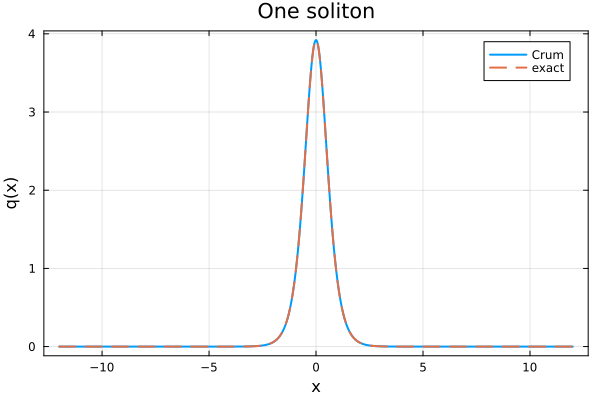

In [20]:
x = collect(range(-12.0, 12.0; length=2001))
kappa = [1.4]
beta = [1.0]
shift = 0.0

q = NI.crum_transform(x, kappa, beta; shifts=[shift])
q_exact = NI.exact_one_soliton(x, kappa[1]; beta=beta[1], shift=shift)

@show NI.relative_l2_error(q, q_exact)

plot(x, q; label="Crum", xlabel="x", ylabel="q(x)", title="One soliton")
plot!(x, q_exact; label="exact", linestyle=:dash)

## Two Solitons

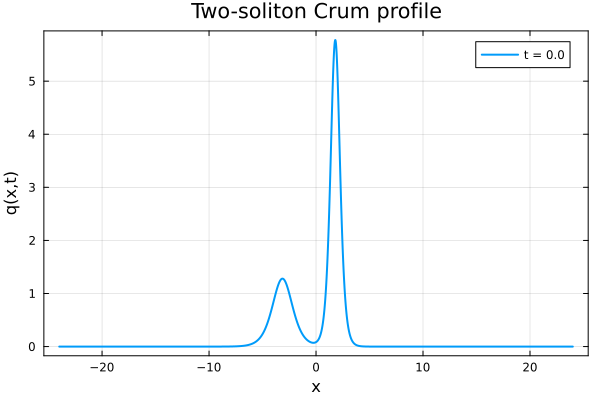

In [21]:
x2 = collect(range(-24.0, 24.0; length=3001))
kappa2 = [0.8, 1.7]
beta2 = NI.alternating_norming_constants(length(kappa2))
shifts2 = [-2.5, 1.5]
t = 0.0

beta2_t = NI.evolve_beta(kappa2, beta2, t)
q2 = NI.crum_transform(x2, kappa2, beta2_t; shifts=shifts2)

plot(x2, q2;
     label="t = $t",
     xlabel="x",
     ylabel="q(x,t)",
     title="Two-soliton Crum profile")

## Time Slice Sweep

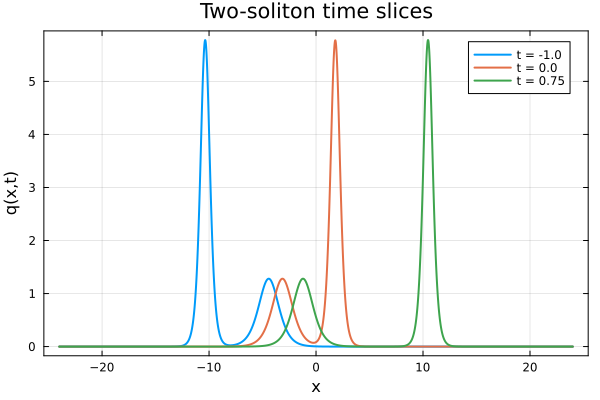

In [22]:
times = [-1.0, 0.0, 0.75]

plt = plot(; xlabel="x", ylabel="q(x,t)", title="Two-soliton time slices")
for t in times
    beta_t = NI.evolve_beta(kappa2, beta2, t)
    q_t = NI.crum_transform(x2, kappa2, beta_t; shifts=shifts2)
    plot!(plt, x2, q_t; label="t = $t")
end
plt

## Paper Algorithm: Finite-Section IST

maximum(abs.(ist_result.q[interior] .- exact92[interior])) = 7.224293832486239e-6


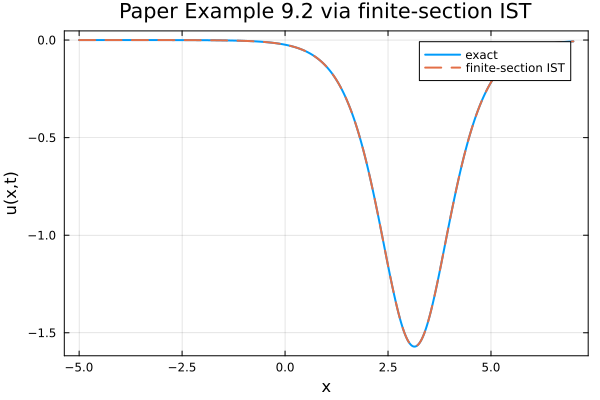

In [23]:
data92 = NI.paper_example92_scattering_data(c=π)
x_ist = collect(range(-5.0, 7.0; length=801))
t_ist = 1.0

ist_result = NI.kdv_ist_solution(data92.right, data92.left, x_ist, t_ist; Ns=8, Ni=256)
exact92 = NI.paper_example92_exact.(x_ist, t_ist)

interior = 5:(length(x_ist)-4)
@show maximum(abs.(ist_result.q[interior] .- exact92[interior]))

plot(x_ist, exact92; label="exact", xlabel="x", ylabel="u(x,t)", title="Paper Example 9.2 via finite-section IST")
plot!(x_ist, ist_result.q; label="finite-section IST", linestyle=:dash)

## Paper Algorithm: Time Evolution Sweep

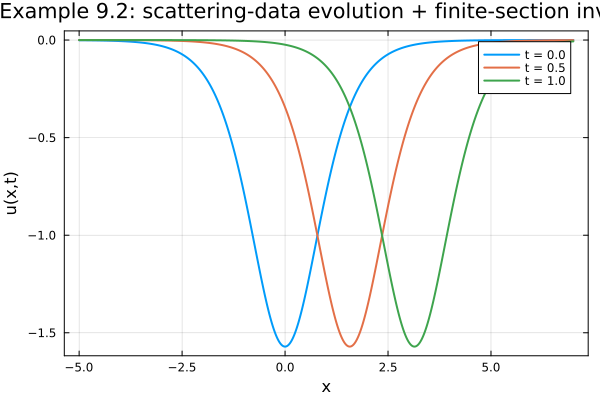

In [24]:
ist_times = [0.0, 0.5, 1.0]

plt = plot(; xlabel="x", ylabel="u(x,t)", title="Example 9.2: scattering-data evolution + finite-section inverse")
for t in ist_times
    result_t = NI.kdv_ist_solution(data92.right, data92.left, x_ist, t; Ns=8, Ni=256)
    plot!(plt, x_ist, result_t.q; label="t = $t")
end
plt

## PDE Time-Step Diagnostic (Not Paper Algorithm)

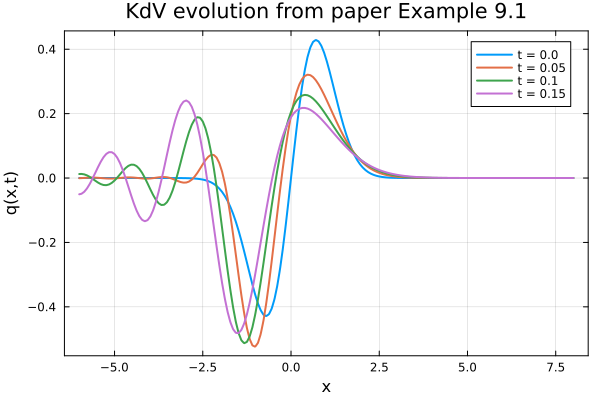

In [25]:
xmin, xmax = -40.0, 40.0
n = 1024
xgrid = collect(range(xmin, xmax; length=n + 1))[1:end-1]
q0 = NI.paper_example91_initial.(xgrid)

evolution_times = [0.0, 0.05, 0.10, 0.15]
sol = NI.solve_kdv_etdrk4(q0, xgrid, evolution_times; dt=5e-4)

xplot = collect(range(-6.0, 8.0; length=800))
plt = plot(; xlabel="x", ylabel="q(x,t)", title="KdV evolution from paper Example 9.1")
for t in evolution_times
    y = NI.interpolate_periodic(xgrid, sol[t], xplot)
    plot!(plt, xplot, y; label="t = $t")
end
plt

## PDE Time-Step Heatmap (Not Paper Algorithm)

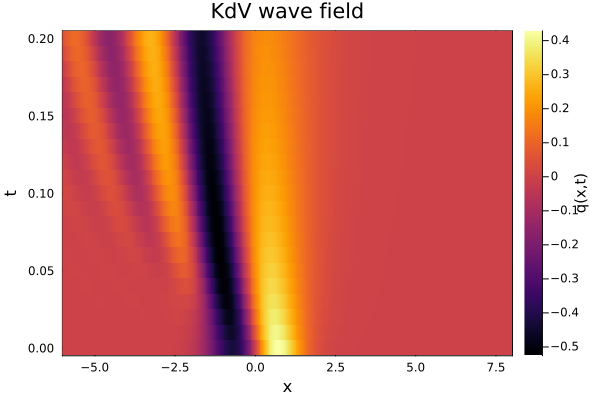

In [26]:
heat_times = collect(0.0:0.01:0.20)
heat_sol = NI.solve_kdv_etdrk4(q0, xgrid, heat_times; dt=5e-4)
heat_x = collect(range(-6.0, 8.0; length=500))

wavefield = hcat([NI.interpolate_periodic(xgrid, heat_sol[t], heat_x) for t in heat_times]...)

heatmap(heat_x, heat_times, permutedims(wavefield);
        xlabel="x",
        ylabel="t",
        colorbar_title="q(x,t)",
        title="KdV wave field")